# ELM-INR: Extreme Learning Machine for Implicit Neural Representations

Implementation of the core ELM-INR method from *"Escaping Spectral Bias without
Backpropagation: Fast Implicit Neural Representations with Extreme Learning Machines"*.

**Key idea:** Represent a grayscale image as a continuous function $\hat{f}(x,y)$ using
multiple **local Extreme Learning Machines** (ELMs) trained independently in closed form
(no backpropagation), blended together with a **partition-of-unity** (PoU).

$$\hat{f}(x,y) = \sum_i \phi_i(x,y)\, \hat{f}_i(x,y)$$

where $\phi_i$ are smooth window functions satisfying $\sum_i \phi_i = 1$,
and each $\hat{f}_i$ is a local ELM:

$$\hat{f}_i(x) = H_i(x)\, \alpha_i, \qquad H_i(x)_j = \sigma(w_{ij}^\top z(x) + b_{ij})$$

with random frozen weights $w, b$ and closed-form output weights $\alpha_i$.

## 1. Imports and Setup

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /myhome/sdate to Python path


In [2]:
import math
import time
from dataclasses import dataclass
from typing import Optional, List, Literal

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")

Device: cuda  |  PyTorch 2.8.0+cu128
GPU: NVIDIA A100 80GB PCIe


## 2. ELM-INR Implementation

The full `ELMINR2D` class with:
- Coordinate generation in $[-1,1]^2$
- Overlapping rectangular subdomains on a regular 2D grid
- Partition-of-unity (PoU) windows (Hann / cosine)
- Random Fourier Features (RFF) for input encoding
- Per-subdomain ELM with closed-form ridge regression
- Full-image reconstruction via PoU blending

In [3]:
@dataclass
class ELMINRConfig:
    """Configuration for the ELM-INR model."""
    # Subdomain grid
    grid_h: int = 8                  # number of subdomains along height
    grid_w: int = 8                  # number of subdomains along width
    overlap: float = 0.25            # fractional overlap between neighbors (0..1)
    expand_dim: int = 512                # number of extra pixels to expand each subdomain (for better blending)

    # Local ELM
    hidden_dim: int = 512            # hidden units per local ELM
    activation: Literal['relu', 'tanh', 'sigmoid'] = 'relu'

    # Input encoding
    use_rff: bool = True             # use Random Fourier Features
    rff_dim: int = 128               # number of RFF frequencies (output is 2*rff_dim)
    rff_sigma: float = 10.0          # std of Gaussian frequency matrix B

    # Solver
    ridge_lambda: float = 1e-4       # Tikhonov regularization

    # Window type for partition of unity
    window: Literal['hann', 'triangular', 'gaussian'] = 'hann'

    # Random seed for reproducibility
    seed: int = 42

In [4]:
class ELMINR2D:
    """
    ELM-INR for 2D grayscale images.

    Represents an image I(x,y) as a sum of local ELMs blended via
    partition-of-unity windows:

        f_hat(x,y) = sum_i  phi_i(x,y) * f_hat_i(x,y)

    where phi_i are smooth windows (sum to 1) and each f_hat_i is an ELM
    with random frozen hidden layer(s) and closed-form output weights.

    Architecture per subdomain
    --------------------------
    Single-layer (expand_dim=0):
        H = σ(z @ W_h + b_h)                     [N, hidden_dim]

    Two-layer (expand_dim > 0):
        H1 = σ(z @ W_h1 + b_h1)                  [N, expand_dim]
        H  = σ(H1 @ W_h2 + b_h2)                 [N, hidden_dim]

    W_h, b_h (or W_h1/b_h1/W_h2/b_h2) are ALL frozen random weights
    regenerable from the seed — they add zero storage cost.
    Only the output weights α_i  [hidden_dim, 1] are stored.
    """

    def __init__(self, cfg: ELMINRConfig, device: torch.device = torch.device('cpu')):
        self.cfg = cfg
        self.device = device
        self.fitted = False

        # Set random seed for reproducible random weights
        self.rng = torch.Generator(device=device)
        self.rng.manual_seed(cfg.seed)

        # RFF frequency matrix B: shape [2, rff_dim]
        # (or [input_dim, rff_dim] — here input_dim=2)
        if cfg.use_rff:
            self.B = torch.randn(2, cfg.rff_dim, generator=self.rng,
                                 device=device) * cfg.rff_sigma
            self.input_dim = 2 * cfg.rff_dim  # cos + sin
        else:
            self.B = None
            self.input_dim = 2  # raw (x, y)

        # Per-subdomain random hidden weights: will be created in _init_subdomains
        self.subdomains: List[dict] = []
        self.alphas: List[torch.Tensor] = []

    # ─── Coordinate generation ────────────────────────────────────────────

    @staticmethod
    def make_coords(H: int, W: int, device: torch.device) -> torch.Tensor:
        """
        Build normalized 2D coordinates in [-1, 1] x [-1, 1].

        Returns:
            coords: [H*W, 2] tensor with (y, x) normalized coordinates.
        """
        ys = torch.linspace(-1, 1, H, device=device)
        xs = torch.linspace(-1, 1, W, device=device)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
        coords = torch.stack([grid_y.flatten(), grid_x.flatten()], dim=-1)  # [N, 2]
        return coords

    # ─── Input feature encoding ──────────────────────────────────────────

    def encode(self, coords: torch.Tensor) -> torch.Tensor:
        """
        Encode coordinates into input features.

        If use_rff: z(x) = [cos(2*pi*B^T x), sin(2*pi*B^T x)]   (2*rff_dim)
        Otherwise:  z(x) = x                                      (2)

        Args:
            coords: [N, 2]
        Returns:
            features: [N, input_dim]
        """
        if self.cfg.use_rff:
            # coords @ B  ->  [N, rff_dim]
            proj = 2.0 * math.pi * (coords @ self.B)
            return torch.cat([torch.cos(proj), torch.sin(proj)], dim=-1)
        else:
            return coords

    # ─── Subdomain generation ────────────────────────────────────────────

    def _init_subdomains(self):
        """
        Create a regular 2D grid of overlapping rectangular subdomains in [-1,1]^2.

        Each subdomain is defined by:
          - center:    (cy, cx)
          - half_size: (hy, hx)  — half-extent including overlap

        With overlap ratio r, the base cell width is 2/grid_w and the
        support half-width is (1+r) * base_half.
        """
        cfg = self.cfg
        base_hy = 1.0 / cfg.grid_h  # half the non-overlapping cell height
        base_hx = 1.0 / cfg.grid_w

        # Expanded half-sizes with overlap
        hy = base_hy * (1.0 + cfg.overlap)
        hx = base_hx * (1.0 + cfg.overlap)

        self.subdomains = []
        for i in range(cfg.grid_h):
            cy = -1.0 + base_hy + 2.0 * base_hy * i  # center y
            for j in range(cfg.grid_w):
                cx = -1.0 + base_hx + 2.0 * base_hx * j  # center x

                if cfg.expand_dim > 0:
                    # Two-layer: input_dim → expand_dim → hidden_dim
                    # Both layers are frozen and regenerable from seed — zero storage cost.
                    std1 = 1.0 / math.sqrt(self.input_dim)
                    W_h1 = torch.randn(self.input_dim, cfg.expand_dim,
                                       generator=self.rng, device=self.device) * std1
                    b_h1 = torch.rand(cfg.expand_dim,
                                      generator=self.rng, device=self.device)  # U[0,1]

                    std2 = 1.0 / math.sqrt(cfg.expand_dim)
                    W_h2 = torch.randn(cfg.expand_dim, cfg.hidden_dim,
                                       generator=self.rng, device=self.device) * std2
                    b_h2 = torch.rand(cfg.hidden_dim,
                                      generator=self.rng, device=self.device)  # U[0,1]

                    self.subdomains.append({
                        'center': (cy, cx),
                        'half_size': (hy, hx),
                        'W_h1': W_h1,  # [input_dim, expand_dim]  — frozen
                        'b_h1': b_h1,  # [expand_dim]             — frozen
                        'W_h2': W_h2,  # [expand_dim, hidden_dim] — frozen
                        'b_h2': b_h2,  # [hidden_dim]             — frozen
                    })
                else:
                    # Single hidden layer: input_dim → hidden_dim
                    # FIX: use U[0,1] bias instead of N(0,1).
                    # With N(0,1) bias, ~50% of ReLU units are dead for the narrow
                    # coordinate range inside small subdomains (16x16 grid).
                    # Dead units → entire H columns are zero → H^T H rank-deficient
                    # → NaN in the solve even with ridge regularisation.
                    # U[0,1] guarantees all biases are positive so ReLU fires
                    # for any non-negative pre-activation, keeping H full-rank.
                    std = 1.0 / math.sqrt(self.input_dim)
                    W_h = torch.randn(self.input_dim, cfg.hidden_dim,
                                      generator=self.rng, device=self.device) * std
                    b_h = torch.rand(cfg.hidden_dim,
                                     generator=self.rng, device=self.device)  # U[0,1]

                    self.subdomains.append({
                        'center': (cy, cx),
                        'half_size': (hy, hx),
                        'W_h': W_h,   # [input_dim, hidden_dim] — frozen
                        'b_h': b_h,   # [hidden_dim]            — frozen
                    })

    # ─── Window (partition of unity) ─────────────────────────────────────

    def _window_1d(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluate 1D unnormalized window on [-1, 1] (zero outside).

        Args:
            t: values in [-1, 1], where 0 = center of subdomain
        Returns:
            weights >= 0, strongest at 0, zero at |t| >= 1
        """
        t = t.clamp(-1, 1)
        if self.cfg.window == 'hann':
            # Hann (raised cosine): 0.5*(1 + cos(pi*t)),  zero at |t|=1
            return 0.5 * (1.0 + torch.cos(math.pi * t))
        elif self.cfg.window == 'triangular':
            return (1.0 - t.abs())
        elif self.cfg.window == 'gaussian':
            # Truncated Gaussian (sigma=0.4)
            return torch.exp(-0.5 * (t / 0.4) ** 2)
        else:
            raise ValueError(f"Unknown window type: {self.cfg.window}")

    def _eval_window(self, coords: torch.Tensor, sub: dict) -> torch.Tensor:
        """
        Evaluate the separable 2D window phi_i(x,y) for one subdomain.

        The window is separable: phi(y,x) = w((y-cy)/hy) * w((x-cx)/hx)

        Args:
            coords: [N, 2]  (y, x)
            sub: subdomain dict with 'center' and 'half_size'
        Returns:
            phi: [N]  non-negative window weights (unnormalized)
        """
        cy, cx = sub['center']
        hy, hx = sub['half_size']

        # Normalized distance from center: in [-1, 1] inside support
        ty = (coords[:, 0] - cy) / hy
        tx = (coords[:, 1] - cx) / hx

        # Zero outside support
        inside = (ty.abs() <= 1.0) & (tx.abs() <= 1.0)
        phi = torch.zeros(coords.shape[0], device=coords.device)
        if inside.any():
            phi[inside] = self._window_1d(ty[inside]) * self._window_1d(tx[inside])
        return phi

    # ─── Hidden-layer forward pass ───────────────────────────────────────

    def _activation(self, x: torch.Tensor) -> torch.Tensor:
        if self.cfg.activation == 'relu':
            return F.relu(x)
        elif self.cfg.activation == 'tanh':
            return torch.tanh(x)
        elif self.cfg.activation == 'sigmoid':
            return torch.sigmoid(x)
        else:
            raise ValueError(f"Unknown activation: {self.cfg.activation}")

    def _hidden_matrix(self, features: torch.Tensor, sub: dict) -> torch.Tensor:
        """
        Compute hidden-layer activations H for a subdomain's ELM.

        Single-layer (expand_dim=0):
            H = sigma(z @ W_h + b_h)             [N, hidden_dim]

        Two-layer (expand_dim > 0):
            H1 = sigma(z @ W_h1 + b_h1)          [N, expand_dim]
            H  = sigma(H1 @ W_h2 + b_h2)         [N, hidden_dim]

        Args:
            features: [N_sub, input_dim]  encoded coordinates within subdomain
            sub: subdomain dict with frozen weight tensors
        Returns:
            H: [N_sub, hidden_dim]
        """
        if 'W_h1' in sub:
            h1 = self._activation(features @ sub['W_h1'] + sub['b_h1'])
            return self._activation(h1 @ sub['W_h2'] + sub['b_h2'])
        return self._activation(features @ sub['W_h'] + sub['b_h'])

    # ─── Closed-form fitting (numerically stable ridge regression) ────────

    def _solve_alpha(self, H: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
        """
        Solve for output weights alpha via the augmented least-squares form
        of ridge regression.

        FIX: the original Cholesky-on-normal-equations approach (H^T H + λI)
        has two failure modes that produce NaN on fine grids (e.g. 16x16):

          1. ReLU dead neurons → entire H columns == 0 → H^T H rank-deficient.
             Even with ridge λ, Cholesky pivots can collapse to ≈λ, and the
             solve produces ±Inf which propagates as NaN.

          2. Corner subdomains with n_pts < hidden_dim → H^T H structurally
             rank-deficient regardless of λ.

          3. The lstsq fallback on CUDA does NOT raise RuntimeError for
             rank-deficient input — it silently returns NaN in .solution.

        The augmented system avoids forming H^T H entirely:

            [H          ]         [Y]
            [sqrt(λ) * I]  alpha = [0]

        torch.linalg.lstsq on this system gives the minimum-norm ridge
        solution while preserving the condition number of H (rather than
        squaring it as H^T H does).  A nan_to_num guard handles any
        residual CUDA edge cases.

        Args:
            H: [N_sub, m]  hidden matrix
            Y: [N_sub, 1]  target values
        Returns:
            alpha: [m, 1]
        """
        m = H.shape[1]
        sqrt_lam = math.sqrt(self.cfg.ridge_lambda)

        # Stack regularisation rows below the data rows
        H_aug = torch.cat(
            [H, sqrt_lam * torch.eye(m, device=H.device, dtype=H.dtype)], dim=0
        )
        Y_aug = torch.cat(
            [Y, torch.zeros(m, 1, device=Y.device, dtype=Y.dtype)], dim=0
        )

        alpha = torch.linalg.lstsq(H_aug, Y_aug).solution  # [m, 1]

        # Guard against any residual NaN/Inf (CUDA lstsq edge case)
        return torch.nan_to_num(alpha, nan=0.0, posinf=0.0, neginf=0.0)

    # ─── Fit ─────────────────────────────────────────────────────────────

    def fit(self, image: torch.Tensor, verbose: bool = True) -> 'ELMINR2D':
        """
        Fit the ELM-INR model to a grayscale image.

        1. Build coordinate grid and flatten
        2. Create overlapping subdomains
        3. For each subdomain:
           a. Select points inside its support
           b. Encode coordinates -> features
           c. Compute hidden matrix H
           d. Solve alpha in closed form

        Args:
            image: [H, W] grayscale image tensor
            verbose: print progress
        Returns:
            self
        """
        assert image.ndim == 2, f"Expected 2D image, got shape {image.shape}"
        self.H, self.W = image.shape

        t0 = time.time()

        # Step 1: coordinates and targets
        coords = self.make_coords(self.H, self.W, self.device)   # [N, 2]
        Y = image.to(self.device).flatten().unsqueeze(-1)         # [N, 1]

        # Step 2: encode all coordinates once (shared RFF matrix B)
        features = self.encode(coords)  # [N, input_dim]

        # Step 3: initialise subdomains (creates random frozen weights)
        self._init_subdomains()
        n_sub = len(self.subdomains)
        if verbose:
            expand_str = (f" → expand={self.cfg.expand_dim} → "
                          if self.cfg.expand_dim > 0 else " → ")
            arch_str = f"{self.input_dim}{expand_str}{self.cfg.hidden_dim}"
            print(f"ELM-INR: {self.cfg.grid_h}x{self.cfg.grid_w} = {n_sub} subdomains, "
                  f"arch=[{arch_str}], overlap={self.cfg.overlap}")
            print(f"  Image: {self.H}x{self.W} = {self.H*self.W:,} pixels")
            print(f"  Input features: {self.input_dim}  "
                  f"({'RFF sigma=' + str(self.cfg.rff_sigma) if self.cfg.use_rff else 'raw coords'})")

        # Step 4: fit each subdomain independently
        self.alphas = []
        total_points = 0
        for sub in self.subdomains:
            # Find points inside this subdomain's support
            cy, cx = sub['center']
            hy, hx = sub['half_size']
            mask = ((coords[:, 0] - cy).abs() <= hy) & \
                   ((coords[:, 1] - cx).abs() <= hx)

            n_pts = mask.sum().item()
            total_points += n_pts

            if n_pts == 0:
                # Empty subdomain — store zero alpha
                self.alphas.append(torch.zeros(self.cfg.hidden_dim, 1,
                                              device=self.device))
                continue

            # Features and targets for this subdomain
            feat_sub = features[mask]  # [n_pts, input_dim]
            Y_sub = Y[mask]            # [n_pts, 1]

            # Hidden matrix
            H_sub = self._hidden_matrix(feat_sub, sub)  # [n_pts, hidden_dim]

            # Closed-form solve
            alpha = self._solve_alpha(H_sub, Y_sub)  # [hidden_dim, 1]
            self.alphas.append(alpha)

        self.fitted = True
        elapsed = time.time() - t0

        if verbose:
            avg_pts = total_points / n_sub
            print(f"  Avg points/subdomain: {avg_pts:,.0f}")
            print(f"  Fit completed in {elapsed:.2f}s (no backpropagation)")

        return self

    # ─── Predict ─────────────────────────────────────────────────────────

    def predict(self, coords: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Evaluate the ELM-INR at arbitrary 2D coordinates.

        For each query point:
          1. Find all subdomains whose support contains it
          2. Evaluate local ELM predictions f_hat_i
          3. Evaluate window weights phi_i
          4. Normalize windows (partition of unity)
          5. Blend:  f_hat = sum_i phi_i * f_hat_i

        Args:
            coords: [N, 2] query points, or None to use the training grid
        Returns:
            values: [N] predicted pixel intensities
        """
        assert self.fitted, "Call fit() first"

        if coords is None:
            coords = self.make_coords(self.H, self.W, self.device)

        N = coords.shape[0]
        features = self.encode(coords)  # [N, input_dim]

        # Accumulate weighted predictions and total window weights
        weighted_sum = torch.zeros(N, device=self.device)
        weight_sum = torch.zeros(N, device=self.device)

        for sub, alpha in zip(self.subdomains, self.alphas):
            # Evaluate window for all query points
            phi = self._eval_window(coords, sub)  # [N]
            active = phi > 0

            if not active.any():
                continue

            # Local ELM prediction for active points
            H_k = self._hidden_matrix(features[active], sub)  # [n_active, hidden_dim]
            pred_k = (H_k @ alpha).squeeze(-1)                 # [n_active]

            # Accumulate
            weighted_sum[active] += phi[active] * pred_k
            weight_sum[active] += phi[active]

        # Normalize by total window weight  (PoU: sum_i phi_i = 1)
        safe_weight = weight_sum.clamp(min=1e-10)
        return weighted_sum / safe_weight

    # ─── Reconstruct image ───────────────────────────────────────────────

    def reconstruct_image(self) -> torch.Tensor:
        """
        Predict on the full training grid and reshape to H x W.

        Returns:
            recon: [H, W] tensor
        """
        vals = self.predict()
        return vals.reshape(self.H, self.W)

    # ─── Storage analysis ────────────────────────────────────────────────

    def storage_bytes(self, dtype_bytes: int = 4) -> dict:
        """
        Estimate the storage required for the ELM-INR representation.

        Stored per subdomain: alpha_i  [hidden_dim, 1]
        Shared: RFF matrix B [2, rff_dim]
        All hidden layer weights (W_h, b_h / W_h1, b_h1, W_h2, b_h2) are
        regenerable from the seed — only the seed needs to be stored.

        Returns dict with byte counts.
        """
        n_sub = len(self.subdomains)
        m = self.cfg.hidden_dim

        # Alpha weights: the only non-random learned parameters
        alpha_bytes = n_sub * m * 1 * dtype_bytes

        # RFF matrix B (shared, must be stored or regenerated from seed)
        if self.cfg.use_rff:
            b_matrix_bytes = 2 * self.cfg.rff_dim * dtype_bytes
        else:
            b_matrix_bytes = 0

        # Hidden weights: random and regenerable from seed (only seed needed)
        if self.cfg.expand_dim > 0:
            # Two-layer: W_h1 [input_dim×expand_dim] + b_h1 [expand_dim]
            #            W_h2 [expand_dim×hidden_dim] + b_h2 [hidden_dim]
            wh_bytes = n_sub * (
                self.input_dim * self.cfg.expand_dim
                + self.cfg.expand_dim
                + self.cfg.expand_dim * m
                + m
            ) * dtype_bytes
        else:
            wh_bytes = n_sub * self.input_dim * m * dtype_bytes
        bh_bytes = 0 if self.cfg.expand_dim > 0 else n_sub * m * dtype_bytes

        # Metadata: grid dims, overlap, seed, etc. (negligible)
        meta_bytes = 64

        return {
            'alpha_bytes': alpha_bytes,
            'rff_B_bytes': b_matrix_bytes,
            'W_h_bytes (regenerable)': wh_bytes,
            'b_h_bytes (regenerable)': bh_bytes,
            'meta_bytes': meta_bytes,
            'total_stored': alpha_bytes + b_matrix_bytes + meta_bytes,
            'total_if_all_stored': alpha_bytes + b_matrix_bytes + wh_bytes + bh_bytes + meta_bytes,
        }


### Quality metrics

In [5]:
from skimage.metrics import structural_similarity as _skimage_ssim
def compute_psnr(pred: np.ndarray, tgt: np.ndarray) -> float:
    dr = float(tgt.max() - tgt.min())
    mse = float(np.mean((np.clip(pred, tgt.min(), tgt.max()) - tgt) ** 2))
    return 10 * math.log10(dr ** 2 / (mse + 1e-10))

def compute_ssim(pred: np.ndarray, tgt: np.ndarray) -> float:
    dr = float(tgt.max() - tgt.min())
    return float(_skimage_ssim(tgt, np.clip(pred, tgt.min(), tgt.max()), data_range=dr))

print("Metric helpers ready")

Metric helpers ready


## 3. Load Dataset and Extract Frames

Uses the same `ProjectionSliceDataset` pipeline as the GSplat notebook.

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Install with: pip install pillow-heif
✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [6814.0000, 51523.0000]
ProjectionSliceDataset:
  Volume shape: (1080, 1280, 10)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,382,400
Loading 10 projections...
Volume shape: (1080, 1280, 10)
Total voxels: 13,824,000
Value range: [8992.6250, 46449.3125]

Volume shape: torch.Size([1080, 1280, 10])
Image size: 1080 x 1280


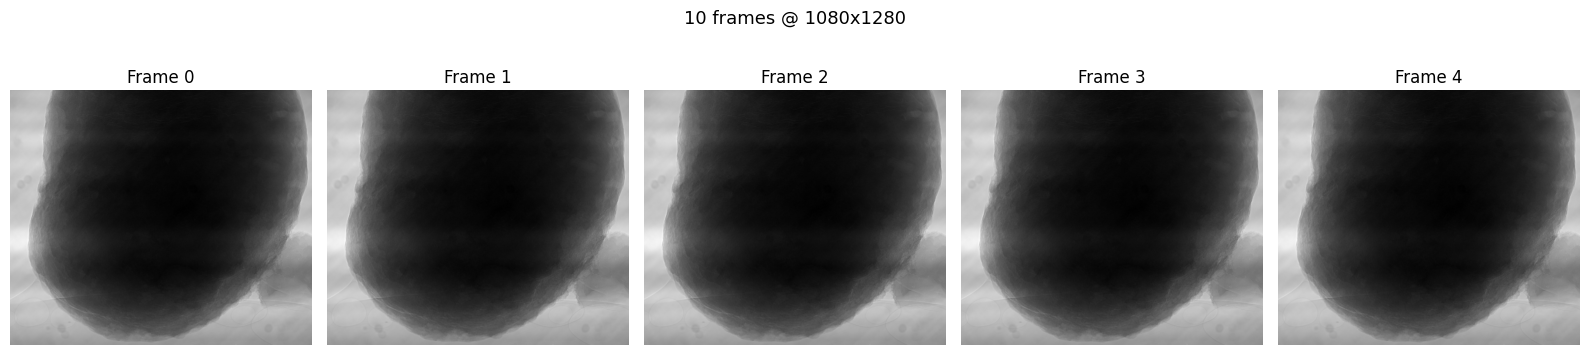

In [9]:
from inct.dataset_slices import ProjectionSliceDataset

DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS = 10
TARGET_SIZE = (2560 // 2, 2160 // 2)  # (1280, 1080) — manageable for ELM fitting

dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=False,
)

volume = dataset.get_full_volume()  # (H, W, D)
H, W = volume.shape[:2]
print(f"\nVolume shape: {volume.shape}")
print(f"Image size: {H} x {W}")

# Extract and per-frame normalise
frames = []
for i in range(NUM_PROJECTIONS):
    img = volume[:, :, i].clone()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    frames.append(img)

# Preview
fig, axes = plt.subplots(1, min(5, len(frames)), figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.imshow(frames[i].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Frame {i}')
    ax.axis('off')
plt.suptitle(f'{len(frames)} frames @ {H}x{W}', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Fit ELM-INR to a Single Frame

Select one frame and fit an ELM-INR representation.
No backpropagation — every local ELM is solved in closed form.

In [10]:
# Select frame to fit
FRAME_IDX = 0
image = frames[FRAME_IDX].to(device)
print(f"Fitting frame {FRAME_IDX}: shape {image.shape}, "
      f"range [{image.min():.4f}, {image.max():.4f}]")

# ── Configure and fit ──────────────────────────────────────────────────
cfg = ELMINRConfig(
    grid_h=16,
    grid_w=16,
    overlap=0.25,
    hidden_dim=1024,        # alpha storage: 16×16×128×4 = 1 MB
    expand_dim=128,       # wide intermediate layer — free (regenerable from seed)
    activation='relu',
    use_rff=True,
    rff_dim=256,
    rff_sigma=5.0,
    ridge_lambda=1e-4,
    window='gaussian',
    seed=42,
)

model = ELMINR2D(cfg, device=device)
model.fit(image, verbose=True)
torch.cuda.empty_cache()


Fitting frame 0: shape torch.Size([1080, 1280]), range [0.0000, 1.0000]
ELM-INR: 16x16 = 256 subdomains, arch=[512 → expand=128 → 1024], overlap=0.25
  Image: 1080x1280 = 1,382,400 pixels
  Input features: 512  (RFF sigma=5.0)
  Avg points/subdomain: 8,221
  Fit completed in 10.53s (no backpropagation)


## 5. Reconstruction and Quality

Reconstruction time: 0.71s

Quality:
  MSE  = 0.000022
  PSNR = 46.49 dB
  SSIM = 0.9816


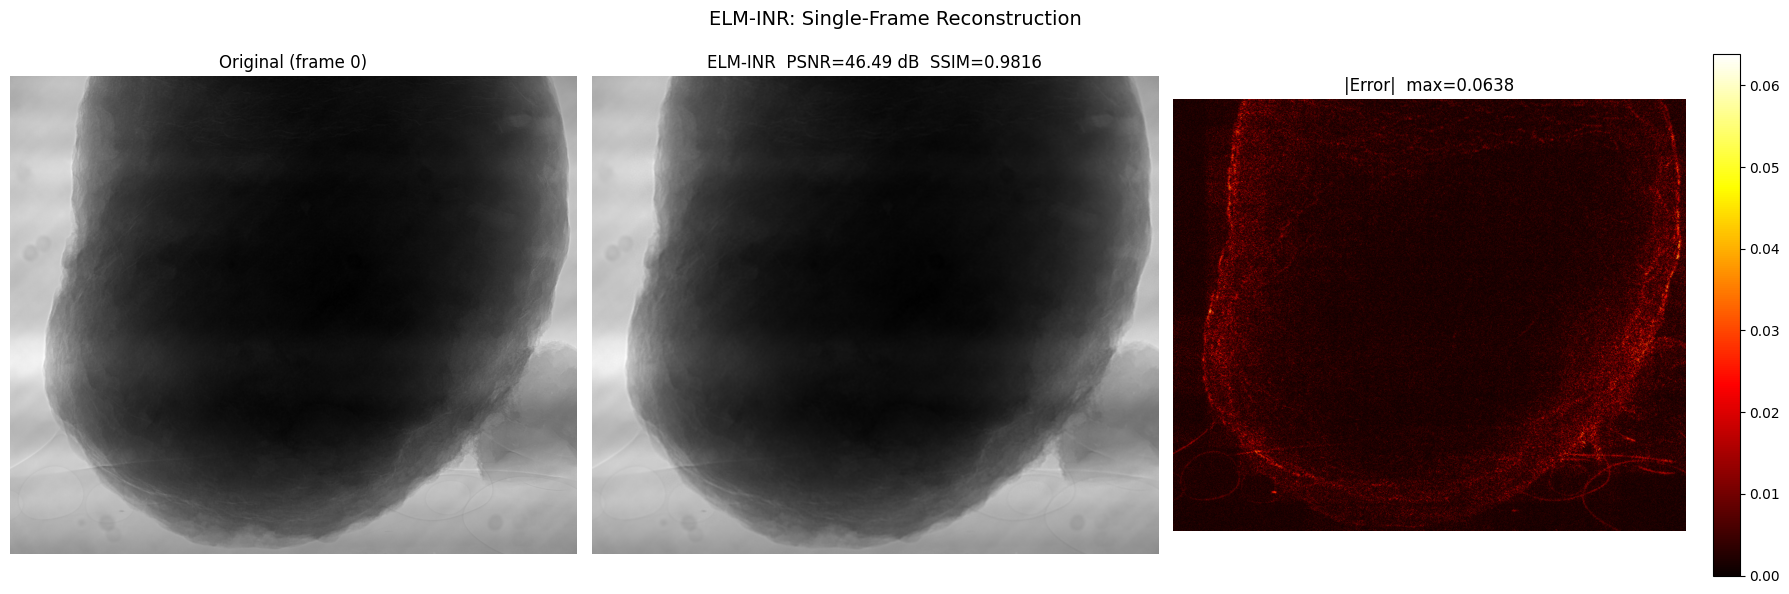

In [ ]:
# ── Reconstruct ───────────────────────────────────────────────────────
t0 = time.time()
recon = model.reconstruct_image()
recon_time = time.time() - t0
print(f"Reconstruction time: {recon_time:.2f}s")

# Clip to valid range
recon_np = recon.clamp(0, 1).cpu().numpy()
orig_np = image.cpu().numpy()

# ── Quality metrics ───────────────────────────────────────────────────
mse_val = np.mean((orig_np - recon_np) ** 2)
psnr_val = compute_psnr(orig_np, recon_np)
ssim_val = compute_ssim(orig_np, recon_np)

print(f"\nQuality:")
print(f"  MSE  = {mse_val:.6f}")
print(f"  PSNR = {psnr_val:.2f} dB")
print(f"  SSIM = {ssim_val:.4f}")

# ── Visualise ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(orig_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Original (frame {FRAME_IDX})', fontsize=12)
axes[0].axis('off')

axes[1].imshow(recon_np, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'ELM-INR  PSNR={psnr_val:.2f} dB  SSIM={ssim_val:.4f}', fontsize=12)
axes[1].axis('off')

err = np.abs(orig_np - recon_np)
im = axes[2].imshow(err, cmap='hot', vmin=0, vmax=err.max())
axes[2].set_title(f'|Error|  max={err.max():.4f}', fontsize=12)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.suptitle('ELM-INR: Single-Frame Reconstruction', fontsize=14)
plt.tight_layout()
plt.show()
torch.cuda.empty_cache()

## 6. Compression Ratio Analysis

The ELM-INR stores:
- **Learned**: output weights $\alpha_i$ per subdomain  ($K \times m \times 1$ floats)
- **Shared / regenerable**: RFF matrix $B$ and hidden weights $W_h, b_h$
  (deterministic from seed — only the seed is needed)

Raw image: $H \times W \times 2$ bytes (int16) or $H \times W \times 4$ bytes (float32).

In [12]:
storage = model.storage_bytes(dtype_bytes=4)  # float32
raw_int16 = H * W * 2
raw_f32 = H * W * 4

print("Storage breakdown (float32):")
for k, v in storage.items():
    print(f"  {k:>30s}: {v:>12,} bytes  ({v/1e6:.3f} MB)")

print(f"\nRaw image sizes:")
print(f"  int16 : {raw_int16:>12,} bytes  ({raw_int16/1e6:.3f} MB)")
print(f"  float32: {raw_f32:>12,} bytes  ({raw_f32/1e6:.3f} MB)")

cr_stored = raw_int16 / storage['total_stored']
cr_all = raw_int16 / storage['total_if_all_stored']

print(f"\nCompression ratio (vs int16 raw):")
print(f"  Seed-regenerable (store alpha + B + meta): {cr_stored:.2f}x")
print(f"  Store everything (alpha + B + W_h + b_h) : {cr_all:.4f}x")

Storage breakdown (float32):
                     alpha_bytes:    1,048,576 bytes  (1.049 MB)
                     rff_B_bytes:        2,048 bytes  (0.002 MB)
         W_h_bytes (regenerable):  202,506,240 bytes  (202.506 MB)
         b_h_bytes (regenerable):            0 bytes  (0.000 MB)
                      meta_bytes:           64 bytes  (0.000 MB)
                    total_stored:    1,050,688 bytes  (1.051 MB)
             total_if_all_stored:  203,556,928 bytes  (203.557 MB)

Raw image sizes:
  int16 :    2,764,800 bytes  (2.765 MB)
  float32:    5,529,600 bytes  (5.530 MB)

Compression ratio (vs int16 raw):
  Seed-regenerable (store alpha + B + meta): 2.63x
  Store everything (alpha + B + W_h + b_h) : 0.0136x


## 7. Ablation: Effect of Grid Resolution and Hidden Dim

Sweep different configurations to see the quality vs. compression trade-off.

In [13]:
ablation_configs = [
    {'grid_h': 4,  'grid_w': 4,  'hidden_dim': 256},
    {'grid_h': 4,  'grid_w': 4,  'hidden_dim': 512},
    {'grid_h': 8,  'grid_w': 8,  'hidden_dim': 256},
    {'grid_h': 8,  'grid_w': 8,  'hidden_dim': 512},
    {'grid_h': 12, 'grid_w': 12, 'hidden_dim': 256},
    {'grid_h': 12, 'grid_w': 12, 'hidden_dim': 512},
    {'grid_h': 16, 'grid_w': 16, 'hidden_dim': 256},
    {'grid_h': 16, 'grid_w': 16, 'hidden_dim': 512},
]

ablation_results = []
image_test = frames[FRAME_IDX].to(device)

for params in ablation_configs:
    c = ELMINRConfig(
        grid_h=params['grid_h'], grid_w=params['grid_w'],
        hidden_dim=params['hidden_dim'],
        overlap=0.25, use_rff=True, rff_dim=128,
        rff_sigma=10.0, ridge_lambda=1e-4,
        window='hann', seed=42,
    )
    m = ELMINR2D(c, device=device)
    t0 = time.time()
    m.fit(image_test, verbose=False)
    fit_t = time.time() - t0

    rec = m.reconstruct_image().clamp(0, 1).cpu().numpy()
    p = compute_psnr(orig_np, rec)
    s = compute_ssim(orig_np, rec)
    st = m.storage_bytes()
    cr = raw_int16 / st['total_stored']

    ablation_results.append({
        'grid': f"{params['grid_h']}x{params['grid_w']}",
        'hidden_dim': params['hidden_dim'],
        'psnr': p, 'ssim': s,
        'stored_kb': st['total_stored'] / 1024,
        'cr': cr, 'fit_time': fit_t,
    })
    print(f"  {params['grid_h']:>2}x{params['grid_w']:<2}  m={params['hidden_dim']:>4}  "
          f"PSNR={p:>6.2f}  SSIM={s:.4f}  CR={cr:>6.2f}x  "
          f"stored={st['total_stored']/1024:.1f}kB  fit={fit_t:.2f}s")

   4x4   m= 256  PSNR= 21.31  SSIM=0.5987  CR=158.24x  stored=17.1kB  fit=0.93s
   4x4   m= 512  PSNR= 25.35  SSIM=0.6652  CR= 81.66x  stored=33.1kB  fit=1.36s
   8x8   m= 256  PSNR= 34.07  SSIM=0.8721  CR= 41.50x  stored=65.1kB  fit=0.84s
   8x8   m= 512  PSNR= 38.98  SSIM=0.9272  CR= 20.92x  stored=129.1kB  fit=1.74s
  12x12  m= 256  PSNR= 40.33  SSIM=0.9433  CR= 18.61x  stored=145.1kB  fit=0.93s
  12x12  m= 512  PSNR= 42.84  SSIM=0.9617  CR=  9.34x  stored=289.1kB  fit=1.94s
  16x16  m= 256  PSNR= 42.41  SSIM=0.9590  CR= 10.50x  stored=257.1kB  fit=1.31s
  16x16  m= 512  PSNR= 44.55  SSIM=0.9724  CR=  5.26x  stored=513.1kB  fit=2.46s


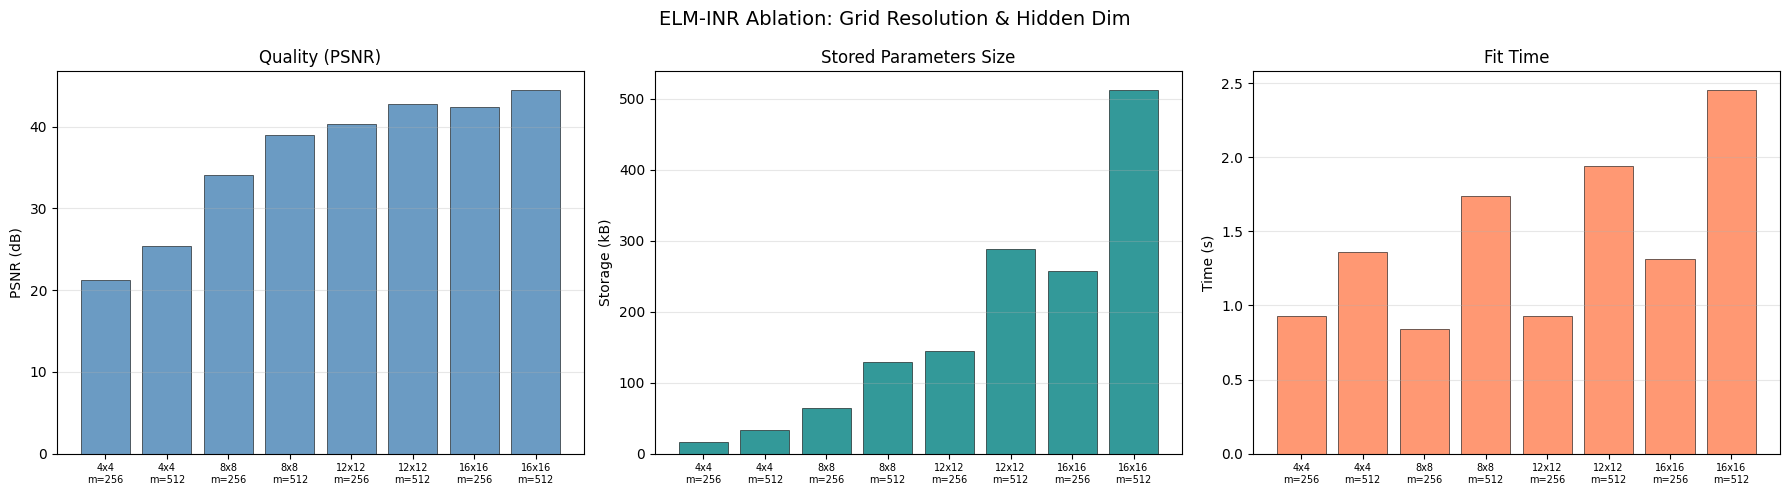

In [14]:
# ── Plot ablation results ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = [f"{r['grid']}\nm={r['hidden_dim']}" for r in ablation_results]
psnrs = [r['psnr'] for r in ablation_results]
crs = [r['cr'] for r in ablation_results]
times = [r['fit_time'] for r in ablation_results]
stored = [r['stored_kb'] for r in ablation_results]

x = np.arange(len(labels))

axes[0].bar(x, psnrs, color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=7)
axes[0].set_ylabel('PSNR (dB)'); axes[0].set_title('Quality (PSNR)')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x, stored, color='teal', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=7)
axes[1].set_ylabel('Storage (kB)'); axes[1].set_title('Stored Parameters Size')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(x, times, color='coral', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, fontsize=7)
axes[2].set_ylabel('Time (s)'); axes[2].set_title('Fit Time')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('ELM-INR Ablation: Grid Resolution & Hidden Dim', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Partition-of-Unity Visualisation

Show the window weights for a few subdomains and verify PoU normalisation.

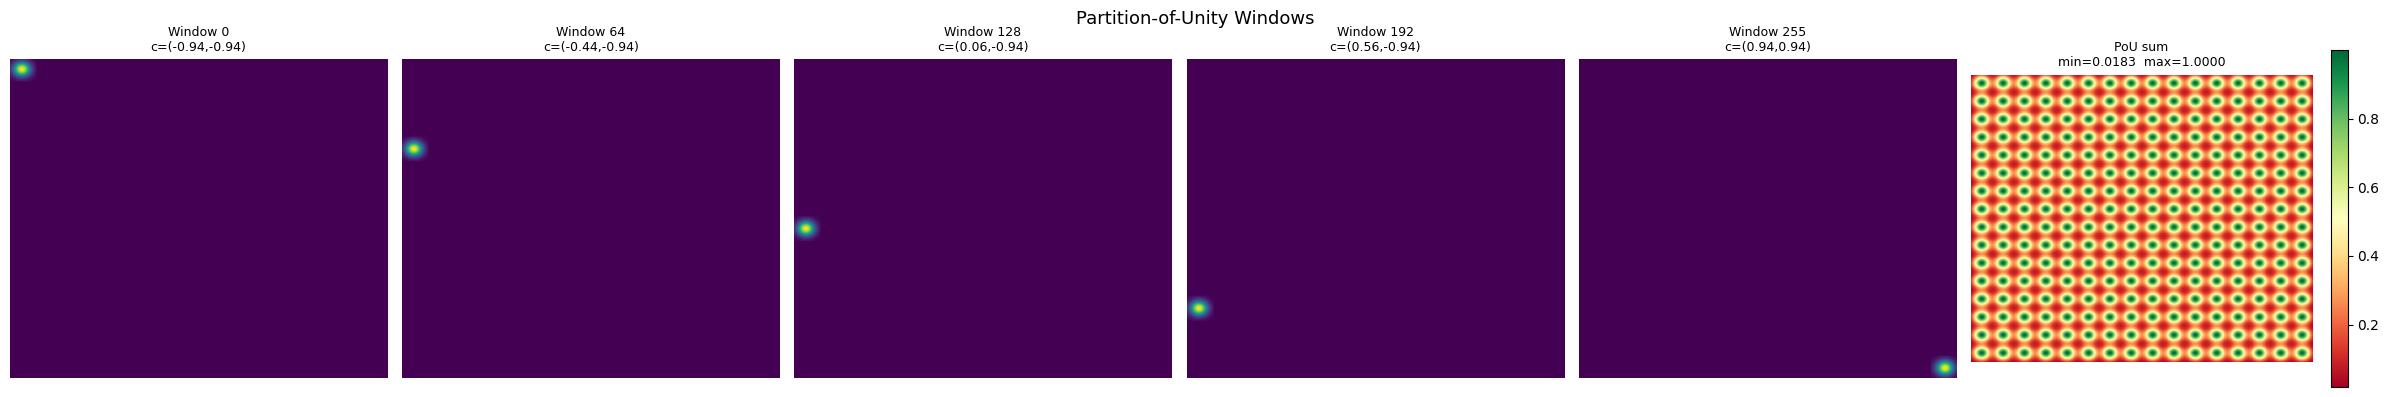

In [15]:
coords = ELMINR2D.make_coords(H, W, device)

# Re-use the best model from section 4
n_sub = len(model.subdomains)

# Sum of all windows (should be ~1 everywhere for correct PoU)
total_weight = torch.zeros(H * W, device=device)
for sub in model.subdomains:
    phi = model._eval_window(coords, sub)
    total_weight += phi

total_weight_img = total_weight.reshape(H, W).cpu().numpy()

# Show a few individual windows and the normalised total
show_indices = [0, n_sub // 4, n_sub // 2, 3 * n_sub // 4, n_sub - 1]
fig, axes = plt.subplots(1, len(show_indices) + 1, figsize=(4 * (len(show_indices) + 1), 4))

for j, idx in enumerate(show_indices):
    phi = model._eval_window(coords, model.subdomains[idx]).reshape(H, W).cpu().numpy()
    axes[j].imshow(phi, cmap='viridis', vmin=0)
    cy, cx = model.subdomains[idx]['center']
    axes[j].set_title(f'Window {idx}\nc=({cy:.2f},{cx:.2f})', fontsize=9)
    axes[j].axis('off')

im = axes[-1].imshow(total_weight_img, cmap='RdYlGn')
axes[-1].set_title(f'PoU sum\nmin={total_weight_img.min():.4f}  max={total_weight_img.max():.4f}', fontsize=9)
axes[-1].axis('off')
plt.colorbar(im, ax=axes[-1], fraction=0.046)

plt.suptitle('Partition-of-Unity Windows', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Multi-Frame Compression

Fit ELM-INR to every frame independently and report per-frame quality and storage.

In [ ]:
# ── Configuration for multi-frame ─────────────────────────────────────
multi_cfg = ELMINRConfig(
    grid_h=12,
    grid_w=12,
    overlap=0.30,
    hidden_dim=512,
    activation='relu',
    use_rff=True,
    rff_dim=128,
    rff_sigma=10.0,
    ridge_lambda=1e-4,
    window='hann',
    seed=42,
)

frame_results = []
models = []

print(f"{'Frame':>6} {'PSNR':>8} {'SSIM':>8} {'Time':>7} {'Stored(kB)':>12} {'CR':>8}")
print("-" * 55)

for i, frame in enumerate(frames):
    m = ELMINR2D(multi_cfg, device=device)
    t0 = time.time()
    m.fit(frame.to(device), verbose=False)
    fit_t = time.time() - t0

    rec = m.reconstruct_image().clamp(0, 1).cpu().numpy()
    tgt = frame.cpu().numpy()
    p = compute_psnr(tgt, rec)
    s = compute_ssim(tgt, rec)
    st = m.storage_bytes()['total_stored']
    cr = raw_int16 / st

    frame_results.append({
        'frame': i, 'psnr': p, 'ssim': s,
        'fit_time': fit_t, 'stored': st, 'cr': cr,
        'recon': rec,
    })
    models.append(m)

    print(f"{i:>6d} {p:>8.2f} {s:>8.4f} {fit_t:>6.1f}s {st/1024:>11.1f} {cr:>8.2f}x")

# ── Summary ────────────────────────────────────────────────────────────
avg_psnr = np.mean([r['psnr'] for r in frame_results])
avg_ssim = np.mean([r['ssim'] for r in frame_results])
total_stored = sum(r['stored'] for r in frame_results)
total_raw = raw_int16 * len(frames)

print(f"\n{'='*55}")
print(f"SUMMARY ({len(frames)} frames)")
print(f"  Avg PSNR : {avg_psnr:.2f} dB")
print(f"  Avg SSIM : {avg_ssim:.4f}")
print(f"  Total stored  : {total_stored/1e6:.3f} MB")
print(f"  Total raw     : {total_raw/1e6:.3f} MB")
print(f"  Overall CR    : {total_raw/total_stored:.2f}x")
print(f"{'='*55}")

 Frame     PSNR     SSIM    Time   Stored(kB)       CR
-------------------------------------------------------
     0    42.63   0.9602    2.2s       289.1     9.34x
     1    42.38   0.9582    2.2s       289.1     9.34x
     2    42.43   0.9586    2.2s       289.1     9.34x
     3    42.39   0.9583    2.2s       289.1     9.34x


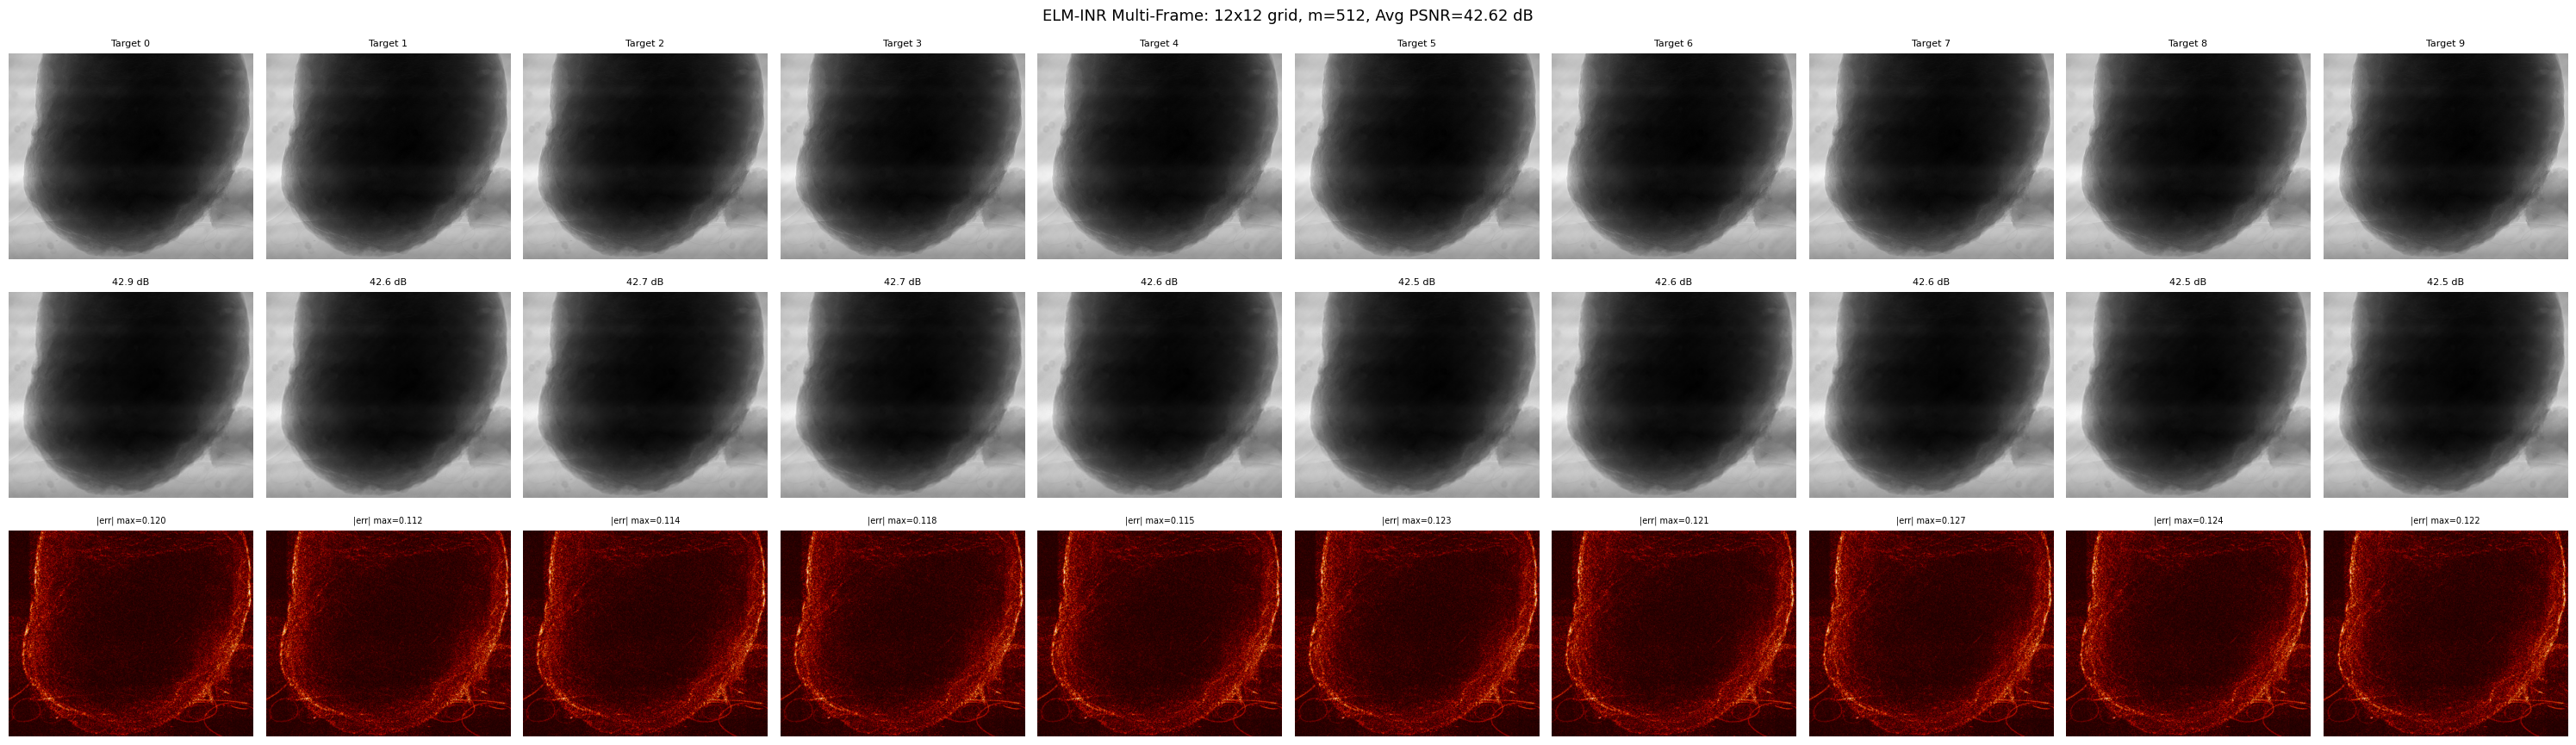

In [ ]:
# ── Show all reconstructed frames ─────────────────────────────────────
n_show = min(len(frames), 10)
fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))

for i in range(n_show):
    tgt = frames[i].cpu().numpy()
    rec = frame_results[i]['recon']
    err = np.abs(tgt - rec)

    axes[0, i].imshow(tgt, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Target {i}', fontsize=8); axes[0, i].axis('off')

    axes[1, i].imshow(rec, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f"{frame_results[i]['psnr']:.1f} dB", fontsize=8)
    axes[1, i].axis('off')

    axes[2, i].imshow(err, cmap='hot', vmin=0, vmax=0.05)
    axes[2, i].set_title(f'|err| max={err.max():.3f}', fontsize=7)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Target', fontsize=10)
axes[1, 0].set_ylabel('Reconstructed', fontsize=10)
axes[2, 0].set_ylabel('|Error|', fontsize=10)

plt.suptitle(f'ELM-INR Multi-Frame: {multi_cfg.grid_h}x{multi_cfg.grid_w} grid, '
             f'm={multi_cfg.hidden_dim}, Avg PSNR={avg_psnr:.2f} dB', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Per-Frame Quality & Compression Curves

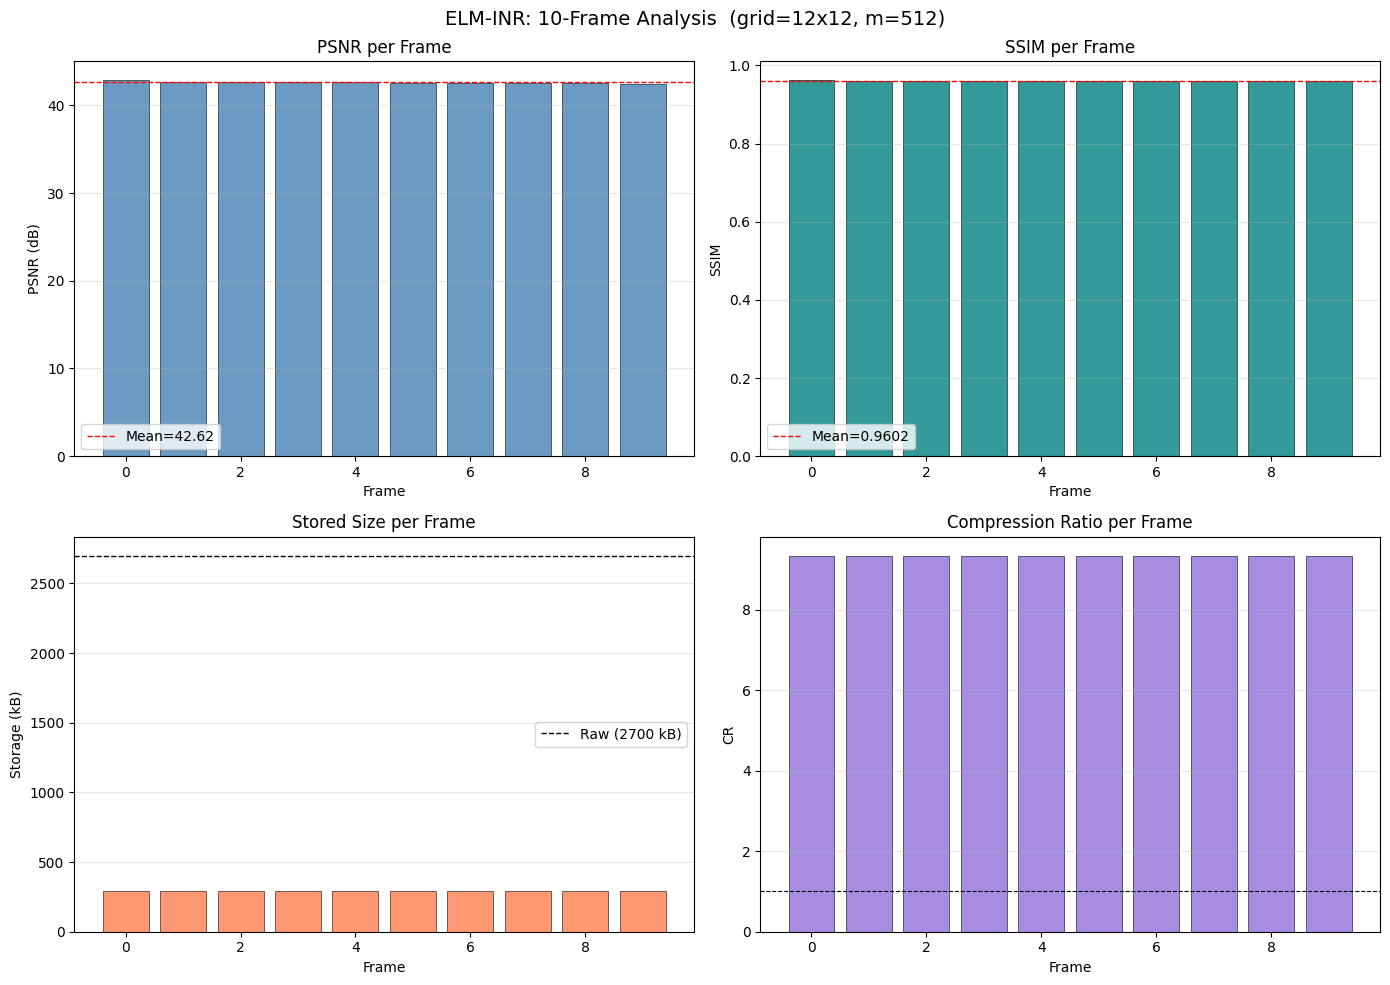

In [ ]:
frame_idxs = [r['frame'] for r in frame_results]
psnrs = [r['psnr'] for r in frame_results]
ssims = [r['ssim'] for r in frame_results]
crs = [r['cr'] for r in frame_results]
stored_kb = [r['stored'] / 1024 for r in frame_results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PSNR
axes[0, 0].bar(frame_idxs, psnrs, color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0, 0].axhline(avg_psnr, color='r', ls='--', lw=1, label=f'Mean={avg_psnr:.2f}')
axes[0, 0].set_xlabel('Frame'); axes[0, 0].set_ylabel('PSNR (dB)')
axes[0, 0].set_title('PSNR per Frame'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3, axis='y')

# SSIM
axes[0, 1].bar(frame_idxs, ssims, color='teal', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0, 1].axhline(avg_ssim, color='r', ls='--', lw=1, label=f'Mean={avg_ssim:.4f}')
axes[0, 1].set_xlabel('Frame'); axes[0, 1].set_ylabel('SSIM')
axes[0, 1].set_title('SSIM per Frame'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3, axis='y')

# Storage
axes[1, 0].bar(frame_idxs, stored_kb, color='coral', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1, 0].axhline(raw_int16 / 1024, color='k', ls='--', lw=1, label=f'Raw ({raw_int16/1024:.0f} kB)')
axes[1, 0].set_xlabel('Frame'); axes[1, 0].set_ylabel('Storage (kB)')
axes[1, 0].set_title('Stored Size per Frame'); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3, axis='y')

# CR
axes[1, 1].bar(frame_idxs, crs, color='mediumpurple', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1, 1].axhline(1.0, color='k', ls='--', lw=0.8)
axes[1, 1].set_xlabel('Frame'); axes[1, 1].set_ylabel('CR')
axes[1, 1].set_title('Compression Ratio per Frame'); axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'ELM-INR: {len(frames)}-Frame Analysis  (grid={multi_cfg.grid_h}x{multi_cfg.grid_w}, '
             f'm={multi_cfg.hidden_dim})', fontsize=14)
plt.tight_layout()
plt.show()

## 11. RFF Sigma Sensitivity

The RFF bandwidth $\sigma$ controls the frequency content the model can capture.
Too low → smooth/blurry; too high → noise/overfitting.

  sigma=  1.0  PSNR=40.52 dB
  sigma=  3.0  PSNR=41.28 dB
  sigma=  5.0  PSNR=41.32 dB
  sigma= 10.0  PSNR=40.39 dB
  sigma= 20.0  PSNR=32.56 dB
  sigma= 40.0  PSNR=28.32 dB


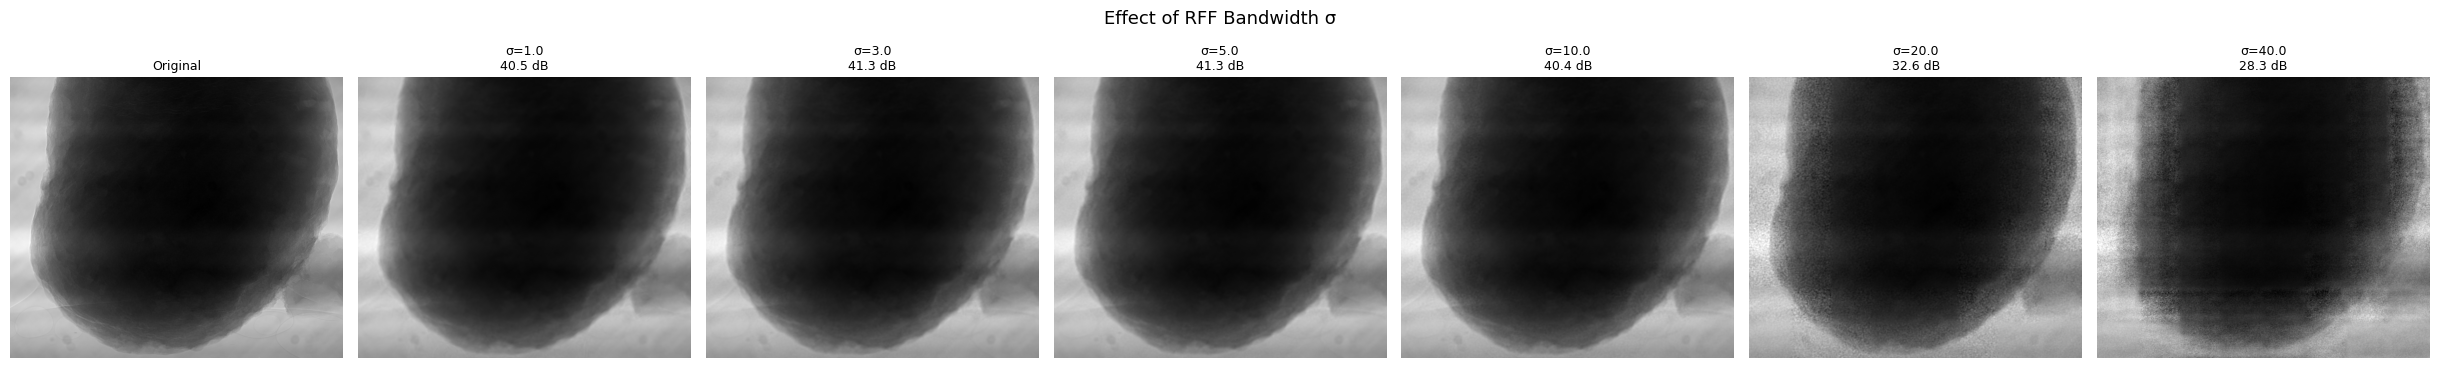

In [ ]:
sigmas = [1.0, 3.0, 5.0, 10.0, 20.0, 40.0]
sigma_results = []

for sigma in sigmas:
    c = ELMINRConfig(
        grid_h=8, grid_w=8, overlap=0.25, hidden_dim=512,
        use_rff=True, rff_dim=128, rff_sigma=sigma,
        ridge_lambda=1e-4, window='hann', seed=42,
    )
    m = ELMINR2D(c, device=device)
    m.fit(image, verbose=False)
    rec = m.reconstruct_image().clamp(0, 1).cpu().numpy()
    p = compute_psnr(orig_np, rec)
    sigma_results.append({'sigma': sigma, 'psnr': p, 'recon': rec})
    print(f"  sigma={sigma:>5.1f}  PSNR={p:.2f} dB")

# ── Visual comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(sigmas) + 1, figsize=(3.5 * (len(sigmas) + 1), 4))
axes[0].imshow(orig_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original', fontsize=9); axes[0].axis('off')
for j, r in enumerate(sigma_results):
    axes[j+1].imshow(r['recon'], cmap='gray', vmin=0, vmax=1)
    axes[j+1].set_title(f"σ={r['sigma']}\n{r['psnr']:.1f} dB", fontsize=9)
    axes[j+1].axis('off')
plt.suptitle('Effect of RFF Bandwidth σ', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Comparison: RFF vs Raw Coordinates

ELM-INR: 8x8 = 64 subdomains, hidden_dim=512, overlap=0.25
  Image: 1080x1280 = 1,382,400 pixels
  Input features: 2  (raw coords)
  Avg points/subdomain: 32,078
  Fit completed in 1.67s (no backpropagation)
ELM-INR: 8x8 = 64 subdomains, hidden_dim=512, overlap=0.25
  Image: 1080x1280 = 1,382,400 pixels
  Input features: 256  (RFF sigma=10.0)
  Avg points/subdomain: 32,078
  Fit completed in 1.70s (no backpropagation)

PSNR without RFF: 36.02 dB
PSNR with RFF:    40.39 dB


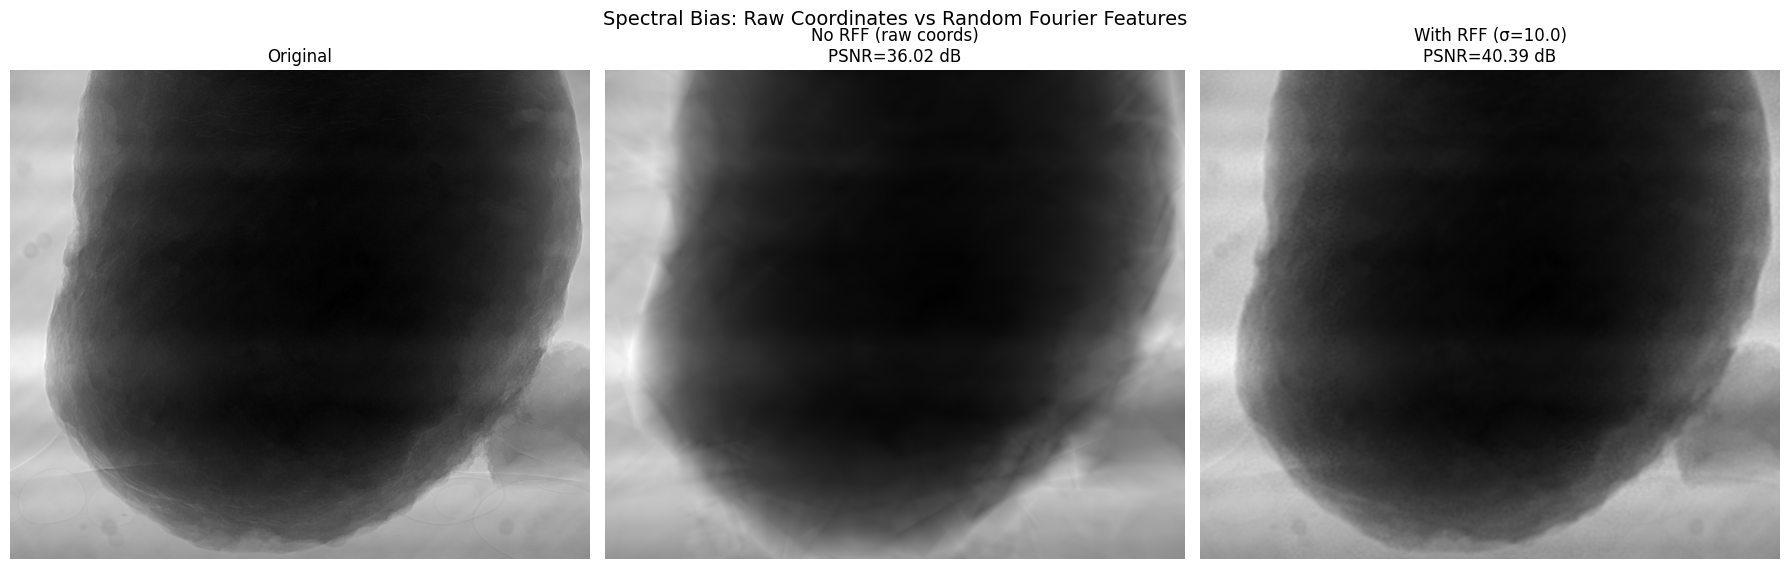

In [ ]:
# ── Without RFF ───────────────────────────────────────────────────────
cfg_no_rff = ELMINRConfig(
    grid_h=8, grid_w=8, overlap=0.25, hidden_dim=512,
    use_rff=False, ridge_lambda=1e-4, window='hann', seed=42,
)
m_no_rff = ELMINR2D(cfg_no_rff, device=device)
m_no_rff.fit(image, verbose=True)
rec_no_rff = m_no_rff.reconstruct_image().clamp(0, 1).cpu().numpy()
psnr_no_rff = compute_psnr(orig_np, rec_no_rff)

# ── With RFF ──────────────────────────────────────────────────────────
cfg_rff = ELMINRConfig(
    grid_h=8, grid_w=8, overlap=0.25, hidden_dim=512,
    use_rff=True, rff_dim=128, rff_sigma=10.0,
    ridge_lambda=1e-4, window='hann', seed=42,
)
m_rff = ELMINR2D(cfg_rff, device=device)
m_rff.fit(image, verbose=True)
rec_rff = m_rff.reconstruct_image().clamp(0, 1).cpu().numpy()
psnr_rff = compute_psnr(orig_np, rec_rff)

print(f"\nPSNR without RFF: {psnr_no_rff:.2f} dB")
print(f"PSNR with RFF:    {psnr_rff:.2f} dB")

# ── Visual ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(orig_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original', fontsize=12); axes[0].axis('off')

axes[1].imshow(rec_no_rff, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'No RFF (raw coords)\nPSNR={psnr_no_rff:.2f} dB', fontsize=12)
axes[1].axis('off')

axes[2].imshow(rec_rff, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f'With RFF (σ={cfg_rff.rff_sigma})\nPSNR={psnr_rff:.2f} dB', fontsize=12)
axes[2].axis('off')

plt.suptitle('Spectral Bias: Raw Coordinates vs Random Fourier Features', fontsize=14)
plt.tight_layout()
plt.show()

## 13. Window Type Comparison

  hann          PSNR=40.39 dB
  triangular    PSNR=40.46 dB
  gaussian      PSNR=40.49 dB


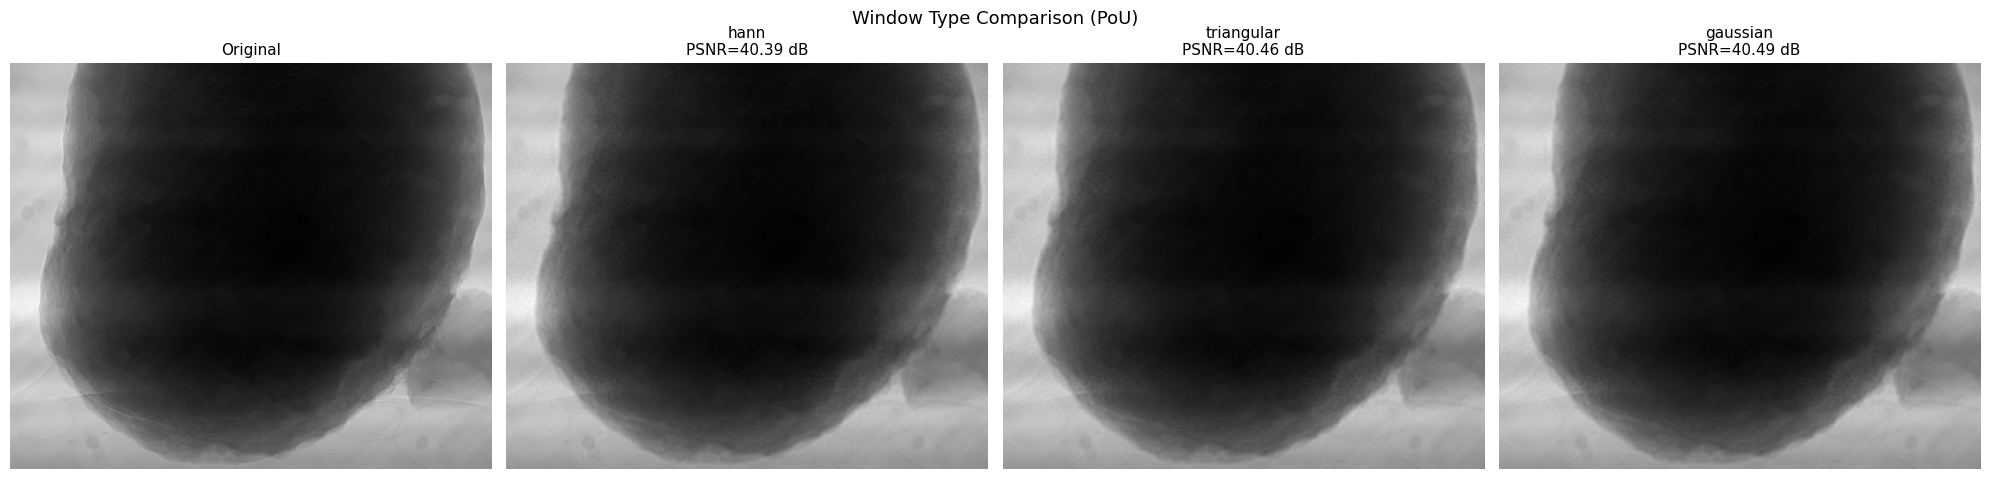

In [ ]:
window_types = ['hann', 'triangular', 'gaussian']
window_results = []

for wt in window_types:
    c = ELMINRConfig(
        grid_h=8, grid_w=8, overlap=0.25, hidden_dim=512,
        use_rff=True, rff_dim=128, rff_sigma=10.0,
        ridge_lambda=1e-4, window=wt, seed=42,
    )
    m = ELMINR2D(c, device=device)
    m.fit(image, verbose=False)
    rec = m.reconstruct_image().clamp(0, 1).cpu().numpy()
    p = compute_psnr(orig_np, rec)
    window_results.append({'window': wt, 'psnr': p, 'recon': rec})
    print(f"  {wt:<12s}  PSNR={p:.2f} dB")

fig, axes = plt.subplots(1, len(window_types) + 1, figsize=(5 * (len(window_types) + 1), 5))
axes[0].imshow(orig_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original', fontsize=11); axes[0].axis('off')
for j, r in enumerate(window_results):
    axes[j+1].imshow(r['recon'], cmap='gray', vmin=0, vmax=1)
    axes[j+1].set_title(f"{r['window']}\nPSNR={r['psnr']:.2f} dB", fontsize=11)
    axes[j+1].axis('off')
plt.suptitle('Window Type Comparison (PoU)', fontsize=13)
plt.tight_layout()
plt.show()

## 14. Summary

| Component | Implementation |
|-----------|---------------|
| **Coordinates** | Normalised $[-1,1]^2$ grid |
| **Input encoding** | Random Fourier Features: $z(x) = [\cos(2\pi B^\top x),\, \sin(2\pi B^\top x)]$ |
| **Subdomains** | Regular overlapping 2D grid with configurable overlap |
| **Window** | Separable Hann / triangular / Gaussian, normalised to PoU |
| **Local model** | Single-hidden-layer ELM: $\hat{f}_i = \sigma(zW_h + b_h)\alpha_i$ |
| **Fitting** | Closed-form ridge regression per subdomain (no backprop) |
| **Blending** | Partition-of-unity: $\hat{f} = \sum_i \phi_i \hat{f}_i / \sum_i \phi_i$ |

**Next steps** (not yet implemented):
- BEAM (Balanced Error Adaptive Meshing) for non-uniform subdomain refinement
- Video / 3D extension
- FP16 quantisation of alpha weights for better compression